###Importing Modules

In [1]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

###Task0: Dataset

In [2]:
names = [
"Aarav","Aarya","Aadhya","Aaditya","Aakash","Aarushi","Aditi","Aditya","Aisha","Akash",
"Akshara","Aman","Amrita","Ananya","Anika","Anil","Anirudh","Anisha","Anjali","Ankit",
"Ansh","Anshika","Anshul","Anu","Anurag","Anusha","Arjun","Arnav","Arpita","Arya",
"Ashish","Ashwin","Avani","Ayaan","Ayush","Ayushi","Bhavya","Chaitanya","Charu","Dev",
"Devansh","Devika","Dhruv","Diya","Divya","Gaurav","Gayatri","Harsh","Ishaan","Isha",
"Ishita","Jai","Janvi","Jatin","Jaya","Karan","Kavya","Krishna","Lakshmi","Manav",
"Meera","Mohan","Naina","Nikhil","Nisha","Om","Parth","Pooja","Pranav","Priya",
"Raghav","Rahul","Raj","Rani","Riya","Rohan","Roshni","Saanvi","Sachin","Sagar",
"Saloni","Samarth","Sanjay","Sanya","Sarika","Shiv","Shivani","Shruti","Siddharth","Simran",
"Sneha","Soham","Sonali","Sourabh","Sudhir","Suman","Suraj","Swati","Tanvi","Tarun",
"Trisha","Uday","Uma","Varun","Vedant","Vikas","Vinay","Vivek","Yash","Yogesh","Zoya"
]

generated = [random.choice(names) for _ in range(1000)]

with open("TrainingNames.txt","w") as f:
    for name in generated:
        f.write(name + "\n")

###Building Vocab

In [3]:
def build_vocab(words):
  # creates a sorted set of all unique characters appearing in all names
    chars = sorted(list(set("".join(words)))) + ['.']

    # maps char to index
    stoi = {s:i for i,s in enumerate(chars)}
    # maps index to character
    itos = {i:s for s,i in stoi.items()}
    return chars, stoi, itos

In [4]:
def encode_words(words, stoi):
    data = []

    for w in words:
       # map every character to its index and append '.' as end token
        seq = [stoi[c] for c in w] + [stoi['.']]
        data.append(seq)
    return data

In [5]:
words = [w.strip().lower() for w in open("TrainingNames.txt")]

chars, stoi, itos = build_vocab(words)
data = encode_words(words, stoi)

vocab_size = len(chars)
print("Vocab Size: ", vocab_size)

Vocab Size:  24


In [6]:
print(chars)

['a', 'b', 'c', 'd', 'e', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'y', 'z', '.']


In [7]:
print(data[0])

[0, 0, 9, 0, 16, 6, 23]


###Training Function

In [8]:
def train_model(model, data, stoi, epochs=30, lr=0.003):
    # loss function for multi-class character prediction
    criterion = nn.CrossEntropyLoss()

    # optimizer to update model parameters
    optimizer = optim.Adam(model.parameters(), lr=lr)
    epoch_losses=[]

    for epoch in range(epochs):
        total_loss = 0

        # iterate over each word
        for word in data:
            loss = 0

            # reset gradients before processing new word
            model.zero_grad()

            # initialize hidden state at start of each sequence
            if hasattr(model, "init_hidden"): hidden = model.init_hidden()

            # store previous hidden states (used only for attention model)
            prev_states = []

            # inputs: start token + all chars except last
            inputs = [stoi['.']] + word[:-1]

            # targets: actual characters including end token
            targets = word

            # iterate through characters of the word
            for i, t in zip(inputs, targets):

                # create one-hot vector for current character
                x = torch.zeros(1, model.vocab_size)
                x[0][i] = 1

                # if model is attention-based, pass previous states
                if model.__class__.__name__ == "RNNAttention":
                    out, hidden = model(x, hidden, prev_states)

                    # store hidden state for future attention
                    prev_states.append(hidden)
                else:
                    # normal RNN / BLSTM forward pass
                    out, hidden = model(x, hidden)

                # compute loss between predicted char and target char
                loss += criterion(out, torch.tensor([t]))

            # backpropagation
            loss.backward()

            # update model parameters
            optimizer.step()

            # accumulate loss
            total_loss += loss.item()

        avg_loss = total_loss / len(data)
        epoch_losses.append(avg_loss)   # store loss

        print(f"Epoch {epoch+1}: {avg_loss:.4f}")
    return epoch_losses

###Generate name using trained model

In [9]:
def generate_name(model, stoi, itos, max_len=20):
    # initialize hidden state
    hidden = model.init_hidden()

    # store previous hidden states (used for attention model)
    prev_states = []

    # start input with start token '.'
    x = torch.zeros(1, model.vocab_size)
    x[0][stoi['.']] = 1

    # store generated characters
    name = ""

    for _ in range(max_len):

        # forward pass
        if model.__class__.__name__ == "RNNAttention":
            # attention model needs previous hidden states
            out, hidden = model(x, hidden, prev_states)
            prev_states.append(hidden)
        else:
            # vanilla RNN / BLSTM
            out, hidden = model(x, hidden)

        # convert logits to probabilities
        prob = torch.softmax(out, dim=1)

        # sample next character index from probability distribution
        idx = torch.multinomial(prob,1).item()

        # stop generation if end token '.' predicted
        if itos[idx] == '.':
            break

        # append predicted character to name
        name += itos[idx]

        # prepare next input as one-hot vector of predicted char
        x = torch.zeros(1, model.vocab_size)
        x[0][idx] = 1

    # return generated name
    return name

###Vanilla RNN

In [10]:
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.vocab_size = vocab_size #vocab size
        self.hidden_size = hidden_size # size of hidden vector

        # input-to-hidden layer: takes concatenated [input + previous hidden] |
        # outputs new hidden state
        self.i2h = nn.Linear(vocab_size + hidden_size, hidden_size)

        #hidden to output layer: convert hidden state to next char score
        self.h2o = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h):
      # combines input vector with the previous hidden state
        combined = torch.cat((x, h), 1)

        # computes new hidden state using tanh activation
        h = torch.tanh(self.i2h(combined))
        # compute output logits ie prob score for next char
        o = self.h2o(h)
        return o, h

    def init_hidden(self):
      # initialize hidden state to zero at the start of seq
        return torch.zeros(1, self.hidden_size)

In [11]:
rnn = VanillaRNN(vocab_size,128)
losses_rnn=train_model(rnn, data, stoi,epochs=30)

Epoch 1: 12.5413
Epoch 2: 8.9733
Epoch 3: 7.1639
Epoch 4: 6.4324
Epoch 5: 6.1149
Epoch 6: 5.9807
Epoch 7: 6.0549
Epoch 8: 5.6653
Epoch 9: 5.5995
Epoch 10: 5.6820
Epoch 11: 6.2402
Epoch 12: 5.4650
Epoch 13: 5.4797
Epoch 14: 5.4324
Epoch 15: 6.2619
Epoch 16: 5.4884
Epoch 17: 5.3893
Epoch 18: 5.4086
Epoch 19: 6.0231
Epoch 20: 5.4865
Epoch 21: 5.4684
Epoch 22: 5.3548
Epoch 23: 5.3812
Epoch 24: 6.4583
Epoch 25: 5.3766
Epoch 26: 5.3502
Epoch 27: 5.4886
Epoch 28: 5.5813
Epoch 29: 5.5524
Epoch 30: 5.4736


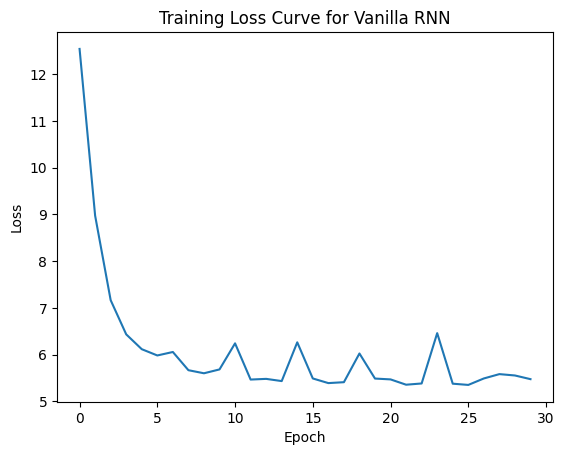

In [12]:
plt.plot(losses_rnn, label="Vanilla RNN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve for Vanilla RNN")
plt.show()

In [13]:
name_gen_rnn = [generate_name(rnn, stoi, itos) for i in range(20)]

print("Generated Names by Vanilla RNN:")
for name in name_gen_rnn:
    print(name)

Generated Names by Vanilla RNN:
anusha
aarav
roshni
siddharth
soham
trisha
bhaina
arjun
akshara
rohan
aditi
anjh
aadhya
om
sarika
sanjay
ansh
arya
ayushi
devika


In [14]:
generated_all = [generate_name(rnn, stoi, itos) for _ in range(1000)]

train_set = set(words)
unique_generated = set(generated_all)

novel_names_rnn = [name for name in unique_generated if name not in train_set]

In [15]:
print("\nGenerated Names not in training data(Vanilla RNN):")
for name in novel_names_rnn[:20]:
    print(name)


Generated Names not in training data(Vanilla RNN):

anudha
anjahi
ranj
rpghav
aadhi
anuran
shchar
anjshi
sudhin
aarhsh
adjtya
swatin
gashal
aninya
arnhv
sonaika
pooj
tanvh
avanir


###BLSTM

In [16]:
class BLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()

        # store vocabulary size and hidden dimension
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

        # bidirectional LSTM layer
        # processes sequence in both forward and backward directions
        # input size = vocab_size (one-hot vector) | hidden size = hidden_size

        self.lstm = nn.LSTM(vocab_size, hidden_size, bidirectional=True)

        # fully connected layer
        # since BLSTM outputs hidden_size*2 (forward + backward); map it back to vocab size (next character prediction)

        self.fc = nn.Linear(hidden_size*2, vocab_size)

    def forward(self, x, h):
        # LSTM expects input shape (seq_len, batch, input_size)
        # current x is (batch, vocab_size), so add seq_len dimension
        x = x.unsqueeze(0)

        # pass through bidirectional LSTM
        out, h = self.lstm(x, h)

        # remove sequence dimension and map to output vocabulary
        out = self.fc(out.squeeze(0))

        # return logits and updated hidden state
        return out, h

    def init_hidden(self):
        # initialize hidden state and cell state with zeros
        # shape = (num_directions, batch, hidden_size)
        # num_directions = 2 because bidirectional
        return (torch.zeros(2,1,self.hidden_size),
                torch.zeros(2,1,self.hidden_size))

In [17]:
blstm = BLSTM(vocab_size,128)
losses_blstm=train_model(blstm, data, stoi)

Epoch 1: 11.8574
Epoch 2: 6.8461
Epoch 3: 5.6615
Epoch 4: 5.3741
Epoch 5: 5.2491
Epoch 6: 5.1743
Epoch 7: 5.1205
Epoch 8: 5.0790
Epoch 9: 5.0462
Epoch 10: 5.0191
Epoch 11: 4.9956
Epoch 12: 4.9750
Epoch 13: 4.9571
Epoch 14: 5.2620
Epoch 15: 4.9051
Epoch 16: 4.9066
Epoch 17: 4.9095
Epoch 18: 4.9087
Epoch 19: 4.9047
Epoch 20: 4.8982
Epoch 21: 4.8904
Epoch 22: 4.8825
Epoch 23: 4.8748
Epoch 24: 4.8675
Epoch 25: 4.8610
Epoch 26: 5.0522
Epoch 27: 4.8332
Epoch 28: 4.8353
Epoch 29: 4.8389
Epoch 30: 4.8410


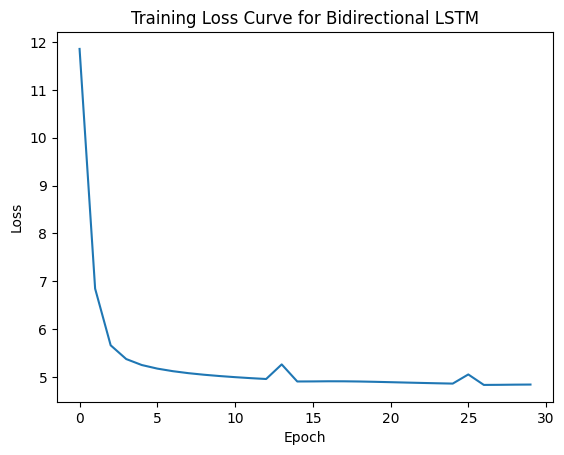

In [18]:
plt.plot(losses_blstm, label="BLSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve for Bidirectional LSTM")
plt.show()

In [23]:
name_gen_blstm = [generate_name(blstm, stoi, itos) for i in range(20)]

print("Generated Names by Bi-directional LSTM:")
for name in name_gen_blstm:
    print(name)

Generated Names by Bi-directional LSTM:
chaitanya
anirudh
aarya
sarika
anu
anusha
aaditya
sarika
vikas
anjali
jatin
nikhil
aditi
tanvi
anuaay
roshni
yogesh
naina
anu
arjun


In [24]:
generated_all = [generate_name(blstm, stoi, itos) for _ in range(1000)]

train_set = set(words)
unique_generated = set(generated_all)

novel_names_blstm = [name for name in unique_generated if name not in train_set]

In [27]:
print("\nGenerated Names not in training data(Bi-directional LSTM):")
for name in novel_names_blstm[:20]:
    print(name)


Generated Names not in training data(Bi-directional LSTM):
anumag
rivika
akjali
devjai
aanisha
rohak
devsnani
arkav
noshan
aesitril
aranya
anvanv
sajanv
ronan
anya
sevinay
viray
urav
nirudh
rojan


###RNN with Basic Attention Mechanism

In [28]:
class RNNAttention(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()

        # store sizes
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

        # computes next hidden state from input + previous hidden
        self.i2h = nn.Linear(vocab_size + hidden_size, hidden_size)

        # attention layer
        # takes [current hidden + previous hidden] and outputs attention score
        self.attn = nn.Linear(hidden_size*2, 1)

        # final output layer (context-> next char logits)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden, prev_states):

        # combine input character and previous hidden state
        combined = torch.cat((x, hidden), 1)

        # compute new hidden state
        hidden = torch.tanh(self.i2h(combined))

        # if no previous states exist
        if len(prev_states) == 0:
            context = hidden

        else:
            # compute attention scores with all previous hidden states
            scores = torch.stack([
                self.attn(torch.cat((hidden, h),1))
                for h in prev_states
            ])

            # flatten to 1D
            scores = scores.view(-1)

            # convert scores to probabilities
            weights = torch.softmax(scores, dim=0)

            # compute weighted sum of previous hidden states
            context = torch.zeros_like(hidden)
            for w,h in zip(weights, prev_states):
                context += w*h

        # use context vector to predict next character
        out = self.fc(context)

        return out, hidden

    def init_hidden(self):
        # initialize hidden state to zero
        return torch.zeros(1,self.hidden_size)

In [29]:
rnn_attn = RNNAttention(vocab_size,128)
losses_rnn_attn=train_model(rnn_attn, data, stoi)

Epoch 1: 15.2576
Epoch 2: 13.4503
Epoch 3: 11.5044
Epoch 4: 10.1223
Epoch 5: 9.5037
Epoch 6: 9.2352
Epoch 7: 9.0514
Epoch 8: 8.9640
Epoch 9: 8.7908
Epoch 10: 8.8491
Epoch 11: 8.6703
Epoch 12: 8.5977
Epoch 13: 8.6813
Epoch 14: 8.6242
Epoch 15: 8.5501
Epoch 16: 8.9129
Epoch 17: 8.4814
Epoch 18: 8.4858
Epoch 19: 8.5357
Epoch 20: 8.5872
Epoch 21: 8.6643
Epoch 22: 8.4377
Epoch 23: 8.5674
Epoch 24: 8.5831
Epoch 25: 8.5281
Epoch 26: 8.4967
Epoch 27: 8.3947
Epoch 28: 8.5948
Epoch 29: 8.4868
Epoch 30: 8.4010


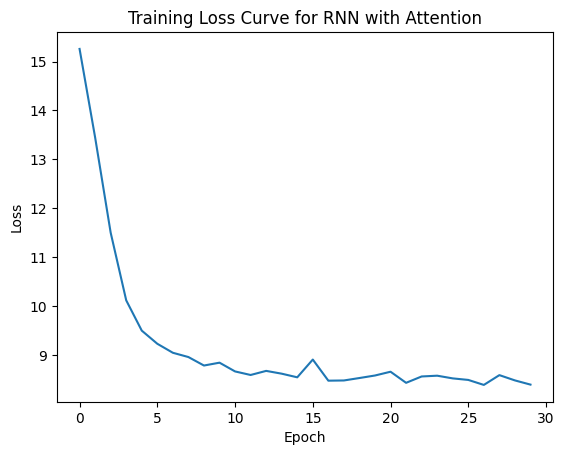

In [30]:
plt.plot(losses_rnn_attn, label="Rnn + Attention")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve for RNN with Attention")
plt.show()

In [31]:
name_gen_rnn_attn = [generate_name(rnn_attn, stoi, itos) for i in range(20)]

print("Generated Names by RNN with attention:")
for name in name_gen_rnn:
    print(name)

Generated Names by RNN with attention:
anusha
aarav
roshni
siddharth
soham
trisha
bhaina
arjun
akshara
rohan
aditi
anjh
aadhya
om
sarika
sanjay
ansh
arya
ayushi
devika


In [43]:
generated_all = [generate_name(rnn, stoi, itos) for i in range(1000)]

train_set = set(words)
unique_generated = set(generated_all)

novel_names_rnn_attn = [name for name in unique_generated if name not in train_set]

In [44]:
print("\nGenerated Names not in training data(RNN with Attention):")
for name in novel_names_rnn_attn[0:20]:
    print(name)


Generated Names not in training data(RNN with Attention):

gashav
anudha
ardhya
artita
vivan
anuran
aarnv
srivit
audhyi
aarhsh
swatin
anshuka
chaitanyath
bhaeya
aarat
tanvh
aika
anuh
eedha


###Task 2: Quantitative Evaluation

In [45]:
def evaluate_model(model, words, stoi, itos, n=1000):

    generated = [generate_name(model, stoi, itos) for _ in range(n)]

    train_set = set(words)
    unique_generated = set(generated)

    novel = [name for name in unique_generated if name not in train_set]

    novelty_rate = len(novel) / len(unique_generated) * 100
    diversity = len(unique_generated) / len(generated)

    return novelty_rate, diversity

In [46]:
for name, model in {"Vanilla RNN": rnn, "BLSTM": blstm, "RNN + Attention": rnn_attn}.items():

    novelty, diversity = evaluate_model(model, words, stoi, itos)

    print(name)
    print("Novelty:", novelty)
    print("Diversity:", diversity)
    print()

Vanilla RNN
Novelty: 45.94594594594595
Diversity: 0.185

BLSTM
Novelty: 20.14388489208633
Diversity: 0.139

RNN + Attention
Novelty: 93.47258485639686
Diversity: 0.766

